Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_3706/1666508837.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


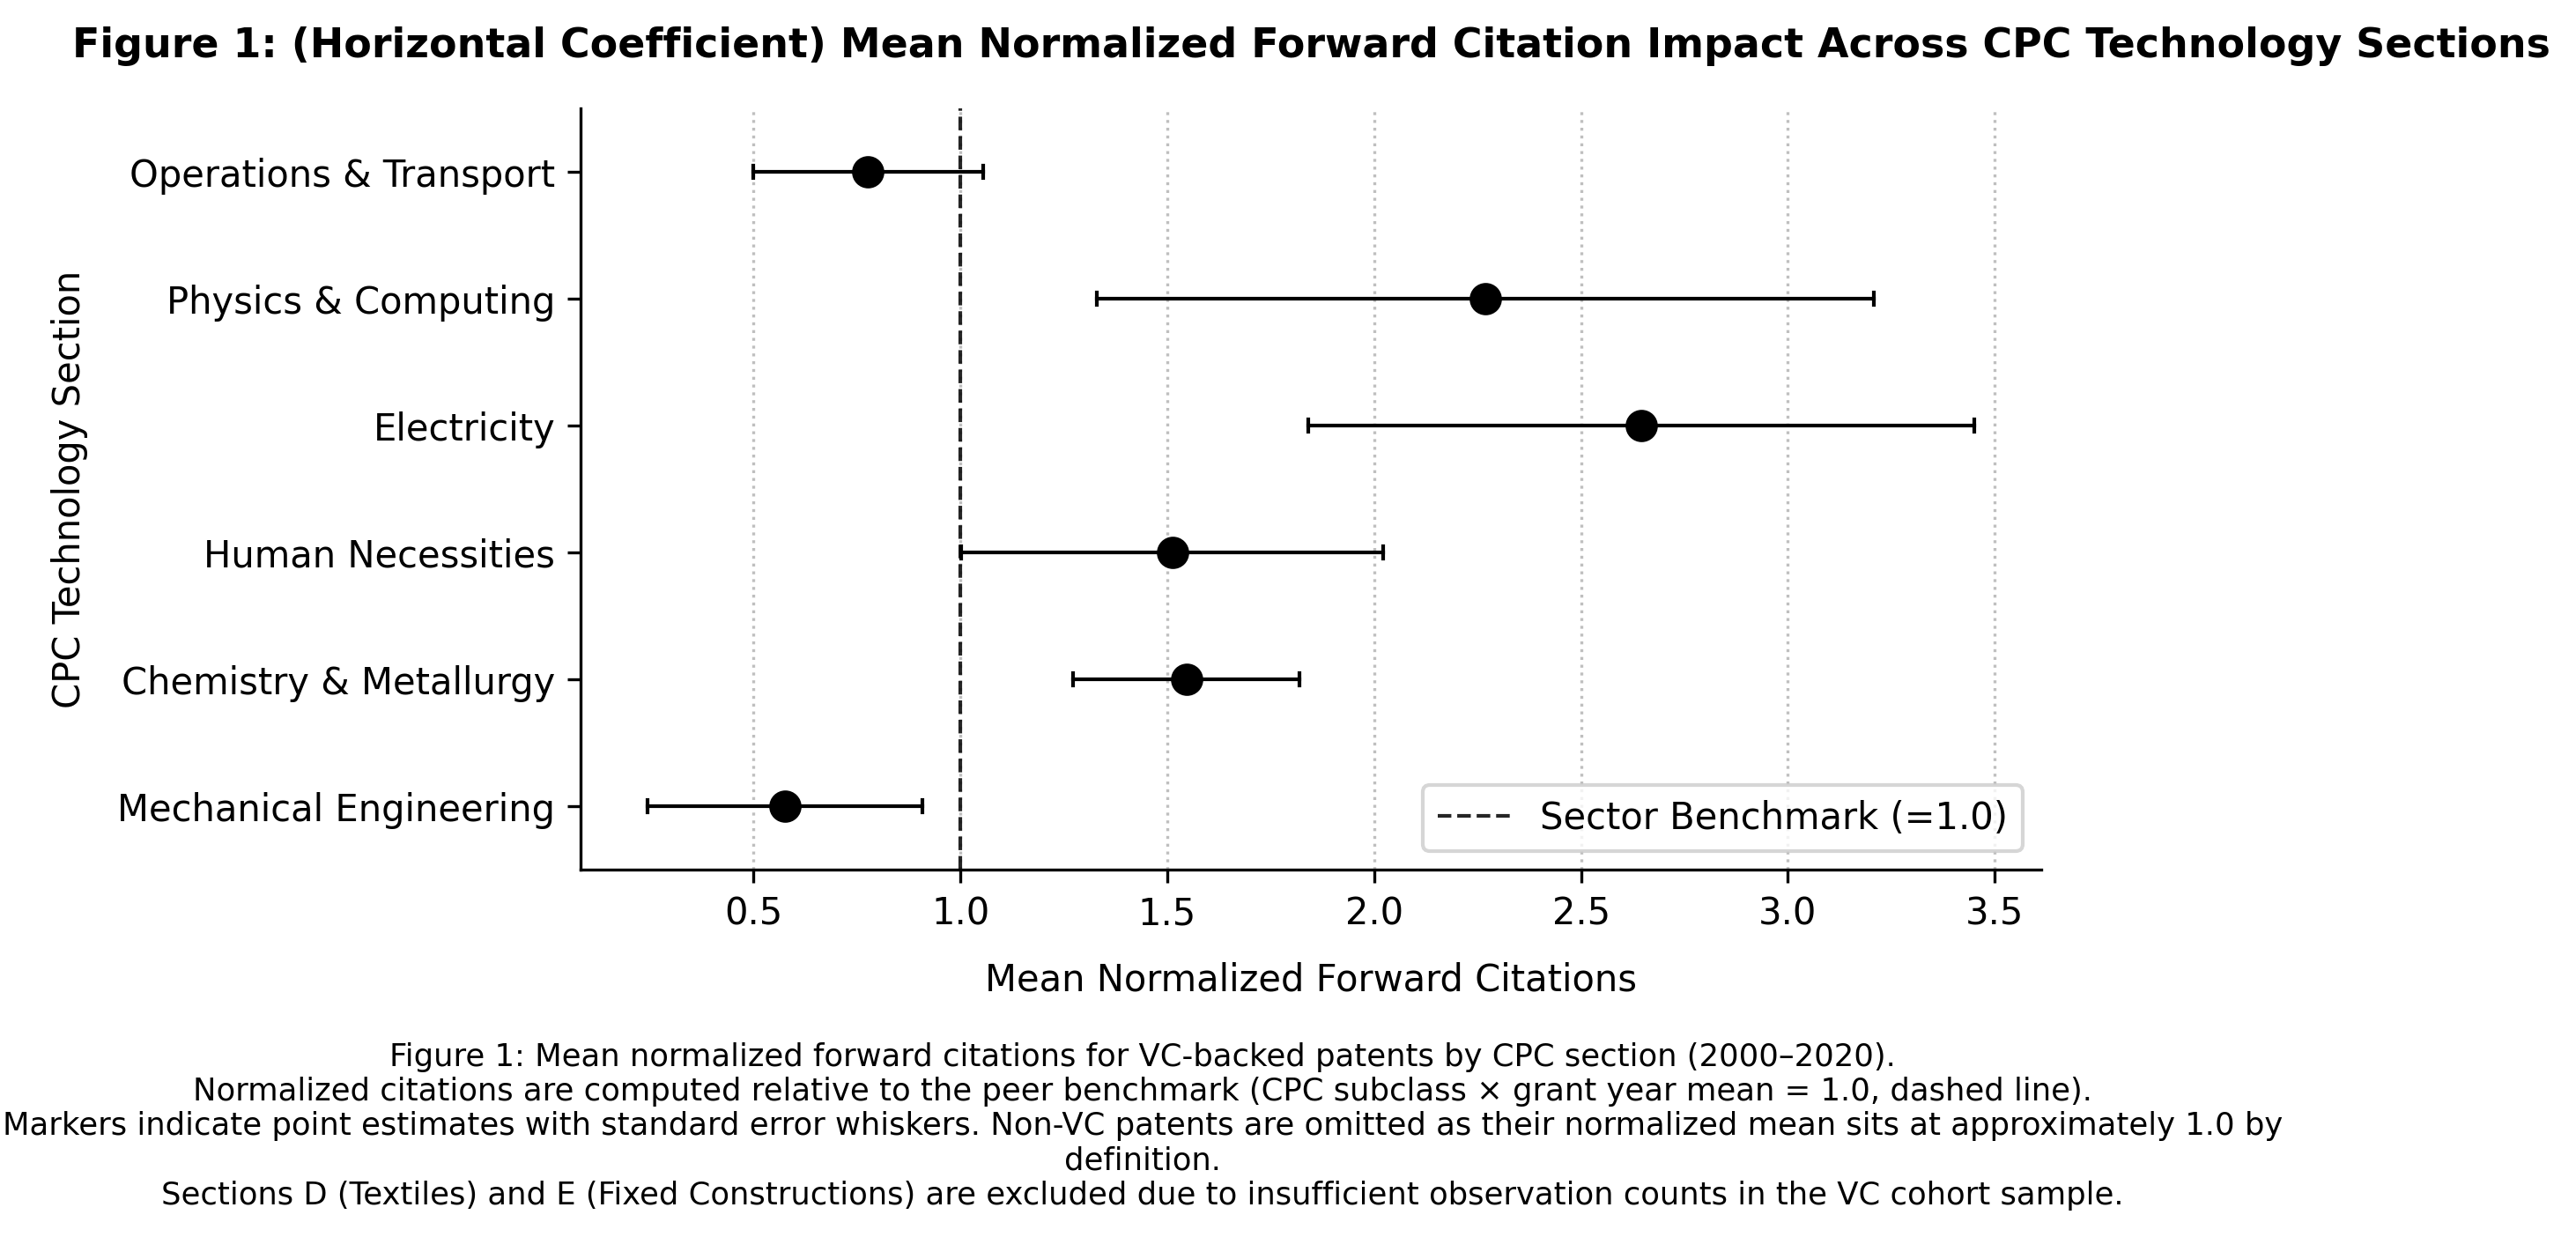

In [3]:
import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

#figure 1

#setup paths and load data
drive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()
df_sec = con.execute(f"""
    SELECT
        CASE cpc_section
            WHEN 'A' THEN 'Human Necessities'
            WHEN 'B' THEN 'Operations & Transport'
            WHEN 'C' THEN 'Chemistry & Metallurgy'
            WHEN 'F' THEN 'Mechanical Engineering'
            WHEN 'G' THEN 'Physics & Computing'
            WHEN 'H' THEN 'Electricity'
        END AS cpc_section,
        normalized_forward_citations
    FROM '{parquet_path}'
    WHERE cpc_section IS NOT NULL
      AND cpc_section NOT IN ('UNKNOWN', 'D', 'E')
      AND vc_backed = 1
      AND normalized_forward_citations IS NOT NULL;
""").df()

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#000000',
    'grid.color': '#000000',
    'grid.alpha': 0.25
})

fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=300)

#horizontal plotpoint
sns.pointplot(
    data=df_sec,
    x='normalized_forward_citations',
    y='cpc_section',
    color='#1f77b4',
    join=False,
    errorbar='se',       #error bars
    capsize=0.1,
    markers='o',
    linestyles='',
    ax=ax
)


plt.setp(ax.collections, edgecolor='#000000', linewidth=0.8)
plt.setp(ax.lines, color='#000000', linewidth=1.0)

#vertical reference at 1
ax.axvline(1.0, color='#000000', linestyle='--', linewidth=1.0, alpha=0.85, label='Sector Benchmark (=1.0)')

ax.set_title('Figure 1: (Horizontal Coefficient) Mean Normalized Forward Citation Impact Across CPC Technology Sections', fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('Mean Normalized Forward Citations', fontsize=10, labelpad=8)
ax.set_ylabel('CPC Technology Section', fontsize=10, labelpad=8)
ax.grid(True, linestyle=':', axis='x') #flip gridlines

ax.legend(frameon=True, loc='lower right')

caption = (
    "Figure 1: Mean normalized forward citations for VC-backed patents by CPC section (2000–2020).\n"
    "Normalized citations are computed relative to the peer benchmark (CPC subclass × grant year mean = 1.0, dashed line).\n"
    "Markers indicate point estimates with standard error whiskers. Non-VC patents are omitted as their normalized mean sits at approximately 1.0 by definition.\n"
    "Sections D (Textiles) and E (Fixed Constructions) are excluded due to insufficient observation counts in the VC cohort sample."
)

#horizontal layout
plt.subplots_adjust(bottom=0.28, left=0.25)
fig.text(0.5, 0.02, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

fig1_path = os.path.join(drive_data_dir, "figure1_vert_cpc_section_citations.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()